<a href="https://colab.research.google.com/github/belinatom/NALAPROJECT/blob/main/nlp_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.5 MB/s eta 0:00:00


In [7]:
import pandas as pd
import numpy as np
import re
import random
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

from gensim.models import Word2Vec, FastText

seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f'✓ Setup complete | Device: {device}')

✓ Setup complete | Device: cpu


In [8]:
csv_path = '/content/swahiliproverbs.csv'
text_col = 'swahili_proverb'
label_col = 'label'

df = pd.read_csv(csv_path)[[text_col, label_col]].dropna().copy()
df[text_col] = df[text_col].astype(str).str.strip()
df[label_col] = df[label_col].astype(str).str.strip()
df = df[df[text_col] != ''].reset_index(drop=True)

print(f'✓ Loaded: {len(df)} proverbs, {df[label_col].nunique()} categories')
df.head(5)

✓ Loaded: 5060 proverbs, 56 categories


,swahili_proverb,label
0,Achekaye kilema hata kwao kipo.,Abuse
1,Afadhali lawama ya wazi.,Abuse
2,Afanyae mzaha na watu humlazimu awe na saburi.,Abuse
3,Ajabu ya kondoo kucheka kioo.,Abuse
4,Ajabu ya ngamia kucheka nundu ya ng'ombe.,Abuse


In [9]:
le = LabelEncoder()
y = le.fit_transform(df[label_col])
x_text = df[text_col].tolist()
num_classes = len(le.classes_)

x_train, x_test, y_train, y_test = train_test_split(
    x_text, y, test_size=0.2, random_state=seed, stratify=y
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=seed, stratify=y_train
)

print(f'✓ Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)}')
print(f'✓ Classes: {num_classes}')

✓ Train: 3643 | Val: 405 | Test: 1012
✓ Classes: 56


In [10]:
def tokenize(texts):
    return [re.findall(r'\b\w+\b', text.lower()) for text in texts]

tokens_train = tokenize(x_train)
tokens_val   = tokenize(x_val)
tokens_test  = tokenize(x_test)

def doc_vec(tokens, model):
    if hasattr(model, 'wv'):
        vecs = [model.wv[w] for w in tokens if w in model.wv]
    else:
        vecs = [model[w] for w in tokens if w in model]
    return np.mean(vecs, axis=0) if vecs else np.zeros(100)

def vec_for_texts(texts, model, tokens=None):
    if tokens is None:
        tokens = tokenize(texts)
    return np.vstack([doc_vec(t, model) for t in tokens])

print('✓ Tokenization complete')
print(f'  Sample: {tokens_train[0]}')

✓ Tokenization complete
  Sample: ['maji', 'yakimwagika', 'hayazoleki']


In [11]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_classes=None):
        super().__init__()
        self.fc1  = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2  = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))


def train_and_evaluate(x_tr, y_tr, x_vl, y_vl, x_te, y_te, tag, input_size, num_classes, epochs=50):
    def to_t(x):
        arr = x.toarray() if hasattr(x, 'toarray') else x
        return torch.FloatTensor(arr).to(device)

    tr_loader = DataLoader(TensorDataset(to_t(x_tr), torch.LongTensor(y_tr).to(device)), batch_size=32, shuffle=True)
    vl_loader = DataLoader(TensorDataset(to_t(x_vl), torch.LongTensor(y_vl).to(device)), batch_size=32)
    te_loader = DataLoader(TensorDataset(to_t(x_te), torch.LongTensor(y_te).to(device)), batch_size=32)

    model     = SimpleMLP(input_size, 128, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        for bx, by in tr_loader:
            optimizer.zero_grad()
            criterion(model(bx), by).backward()
            optimizer.step()

        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for bx, by in vl_loader:
                preds.extend(torch.max(model(bx), 1)[1].cpu().numpy())
                targets.extend(by.cpu().numpy())

        val_acc = accuracy_score(targets, preds)
        val_f1  = f1_score(targets, preds, average='macro', zero_division=0)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_f1  = val_f1
            torch.save(model.state_dict(), f'/tmp/best_{tag}.pth')

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{epochs} | Val Acc={val_acc:.4f} F1={val_f1:.4f}')

    model.load_state_dict(torch.load(f'/tmp/best_{tag}.pth'))
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for bx, by in te_loader:
            preds.extend(torch.max(model(bx), 1)[1].cpu().numpy())
            targets.extend(by.cpu().numpy())

    test_acc = accuracy_score(targets, preds)
    test_f1  = f1_score(targets, preds, average='macro', zero_division=0)

    print(f'\n✓ {tag} | Val Acc={best_val_acc:.4f} Val F1={best_val_f1:.4f}')
    print(f'✓ {tag} | Test Acc={test_acc:.4f} Test F1={test_f1:.4f}')

    return {'tag': tag, 'val_acc': best_val_acc, 'val_f1': best_val_f1, 'test_acc': test_acc, 'test_f1': test_f1}

print('✓ Model defined')

✓ Model defined


In [12]:
print('='*60)
print('EXPERIMENT 1: TF-IDF')
print('='*60)

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=1000)
x_tr_tfidf = normalize(tfidf.fit_transform(x_train))
x_vl_tfidf = normalize(tfidf.transform(x_val))
x_te_tfidf = normalize(tfidf.transform(x_test))

results_tfidf = train_and_evaluate(
    x_tr_tfidf, y_train, x_vl_tfidf, y_val, x_te_tfidf, y_test,
    'TF-IDF', x_tr_tfidf.shape[1], num_classes
)

EXPERIMENT 1: TF-IDF
  Epoch 10/50 | Val Acc=0.2444 F1=0.1940
  Epoch 20/50 | Val Acc=0.2247 F1=0.1858
  Epoch 30/50 | Val Acc=0.2049 F1=0.1725
  Epoch 40/50 | Val Acc=0.2074 F1=0.1774
  Epoch 50/50 | Val Acc=0.1975 F1=0.1744

✓ TF-IDF | Val Acc=0.2444 Val F1=0.1940
✓ TF-IDF | Test Acc=0.2401 Test F1=0.2203


In [13]:
print('='*60)
print('EXPERIMENT 2: WORD2VEC (1 EPOCH)')
print('='*60)

w2v_1 = Word2Vec(sentences=tokens_train, vector_size=100, window=5,
                 min_count=2, sg=1, epochs=1, seed=seed, workers=1)

x_tr_w2v1 = vec_for_texts(x_train, w2v_1, tokens_train)
x_vl_w2v1 = vec_for_texts(x_val,   w2v_1, tokens_val)
x_te_w2v1 = vec_for_texts(x_test,  w2v_1, tokens_test)

results_w2v_1 = train_and_evaluate(
    x_tr_w2v1, y_train, x_vl_w2v1, y_val, x_te_w2v1, y_test,
    'W2V-1', 100, num_classes
)

EXPERIMENT 2: WORD2VEC (1 EPOCH)
  Epoch 10/50 | Val Acc=0.0494 F1=0.0017
  Epoch 20/50 | Val Acc=0.0691 F1=0.0116
  Epoch 30/50 | Val Acc=0.0667 F1=0.0082
  Epoch 40/50 | Val Acc=0.0716 F1=0.0112
  Epoch 50/50 | Val Acc=0.0765 F1=0.0150

✓ W2V-1 | Val Acc=0.0765 Val F1=0.0150
✓ W2V-1 | Test Acc=0.0761 Test F1=0.0146


In [14]:
print('='*60)
print('EXPERIMENT 3: WORD2VEC (10 EPOCHS)')
print('='*60)

w2v_10 = Word2Vec(sentences=tokens_train, vector_size=100, window=5,
                  min_count=2, sg=1, epochs=10, seed=seed, workers=1)

x_tr_w2v10 = vec_for_texts(x_train, w2v_10, tokens_train)
x_vl_w2v10 = vec_for_texts(x_val,   w2v_10, tokens_val)
x_te_w2v10 = vec_for_texts(x_test,  w2v_10, tokens_test)

results_w2v_10 = train_and_evaluate(
    x_tr_w2v10, y_train, x_vl_w2v10, y_val, x_te_w2v10, y_test,
    'W2V-10', 100, num_classes
)

EXPERIMENT 3: WORD2VEC (10 EPOCHS)
  Epoch 10/50 | Val Acc=0.0494 F1=0.0032
  Epoch 20/50 | Val Acc=0.0494 F1=0.0046
  Epoch 30/50 | Val Acc=0.0543 F1=0.0081
  Epoch 40/50 | Val Acc=0.0568 F1=0.0059
  Epoch 50/50 | Val Acc=0.0568 F1=0.0066

✓ W2V-10 | Val Acc=0.0593 Val F1=0.0058
✓ W2V-10 | Test Acc=0.0553 Test F1=0.0054


Visualizing Word2Vec embedding shifts...


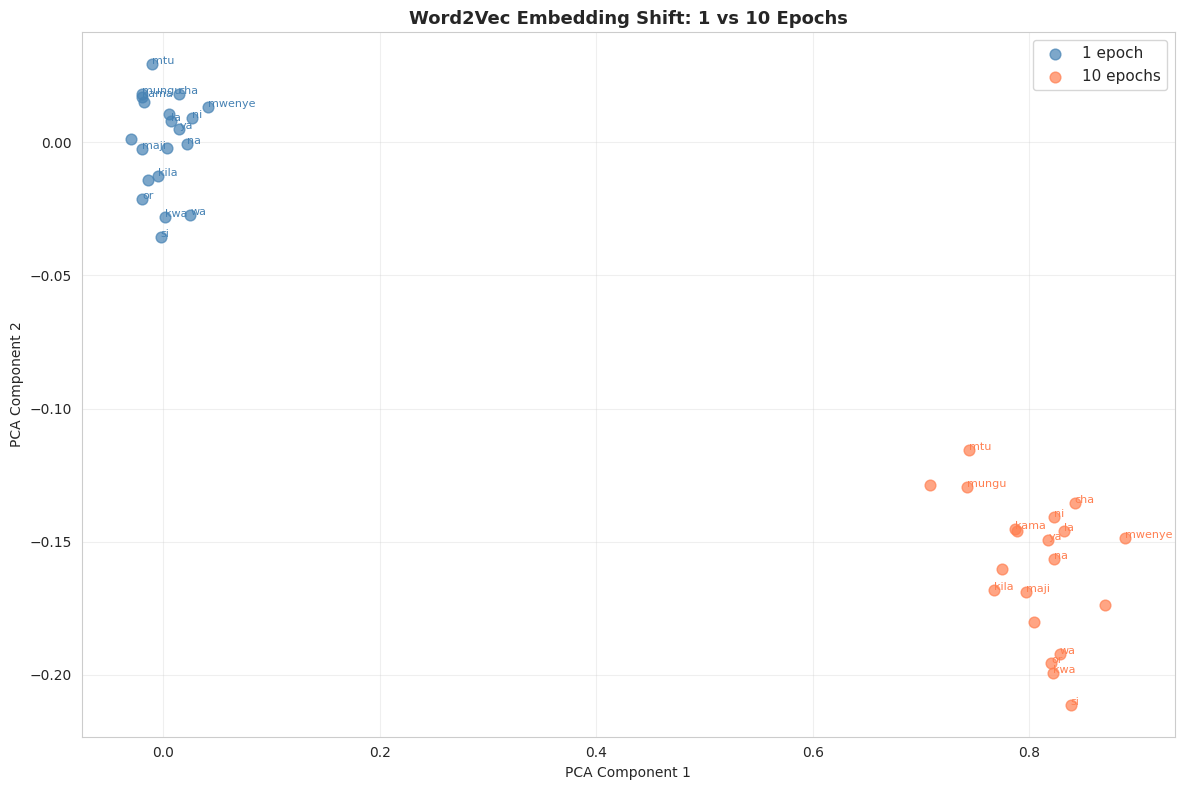

In [15]:
print('Visualizing Word2Vec embedding shifts...')

common_words = pd.Series(np.concatenate(tokens_train)).value_counts().head(20).index.tolist()
common_words = [w for w in common_words if w in w2v_1.wv and w in w2v_10.wv]

emb1  = np.vstack([w2v_1.wv[w]  for w in common_words])
emb10 = np.vstack([w2v_10.wv[w] for w in common_words])

pca    = PCA(n_components=2, random_state=seed)
e1_2d  = pca.fit_transform(emb1)
e10_2d = pca.transform(emb10)

plt.figure(figsize=(12, 8))
plt.scatter(e1_2d[:,0],  e1_2d[:,1],  s=60, label='1 epoch',   alpha=0.7, color='steelblue')
plt.scatter(e10_2d[:,0], e10_2d[:,1], s=60, label='10 epochs', alpha=0.7, color='coral')

for i, word in enumerate(common_words[:15]):
    plt.annotate(word, (e1_2d[i,0],  e1_2d[i,1]),  fontsize=8, color='steelblue')
    plt.annotate(word, (e10_2d[i,0], e10_2d[i,1]), fontsize=8, color='coral')

plt.title('Word2Vec Embedding Shift: 1 vs 10 Epochs', fontsize=13, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
print('='*60)
print('EXPERIMENT 4: FASTTEXT')
print('='*60)

ft = FastText(sentences=tokens_train, vector_size=100, window=5,
              min_count=2, sg=1, epochs=10, seed=seed, workers=1)

x_tr_ft = vec_for_texts(x_train, ft, tokens_train)
x_vl_ft = vec_for_texts(x_val,   ft, tokens_val)
x_te_ft = vec_for_texts(x_test,  ft, tokens_test)

results_ft = train_and_evaluate(
    x_tr_ft, y_train, x_vl_ft, y_val, x_te_ft, y_test,
    'FastText', 100, num_classes
)

EXPERIMENT 4: FASTTEXT
  Epoch 10/50 | Val Acc=0.0494 F1=0.0017
  Epoch 20/50 | Val Acc=0.0494 F1=0.0017
  Epoch 30/50 | Val Acc=0.0494 F1=0.0017
  Epoch 40/50 | Val Acc=0.0420 F1=0.0027
  Epoch 50/50 | Val Acc=0.0494 F1=0.0017

✓ FastText | Val Acc=0.0519 Val F1=0.0028
✓ FastText | Test Acc=0.0474 Test F1=0.0021


In [17]:
print('='*60)
print('EXPERIMENT 5: CHARACTER N-GRAMS TF-IDF')
print('='*60)

char_tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 6), max_features=1000)
x_tr_char = normalize(char_tfidf.fit_transform(x_train))
x_vl_char = normalize(char_tfidf.transform(x_val))
x_te_char = normalize(char_tfidf.transform(x_test))

results_char = train_and_evaluate(
    x_tr_char, y_train, x_vl_char, y_val, x_te_char, y_test,
    'Char-NGrams', x_tr_char.shape[1], num_classes
)

EXPERIMENT 5: CHARACTER N-GRAMS TF-IDF
  Epoch 10/50 | Val Acc=0.2494 F1=0.1958
  Epoch 20/50 | Val Acc=0.2543 F1=0.2175
  Epoch 30/50 | Val Acc=0.2494 F1=0.2229
  Epoch 40/50 | Val Acc=0.2370 F1=0.2129
  Epoch 50/50 | Val Acc=0.2321 F1=0.2135

✓ Char-NGrams | Val Acc=0.2667 Val F1=0.2388
✓ Char-NGrams | Test Acc=0.2144 Test F1=0.2068



TASK 1 — FINAL RESULTS
              val_acc    val_f1  test_acc   test_f1
tag                                                
TF-IDF       0.244444  0.193993  0.240119  0.220296
W2V-1        0.076543  0.014981  0.076087  0.014629
W2V-10       0.059259  0.005828  0.055336  0.005425
FastText     0.051852  0.002780  0.047431  0.002097
Char-NGrams  0.266667  0.238784  0.214427  0.206837

✓ Best (Test Acc): TF-IDF
✓ Best (Test F1):  TF-IDF


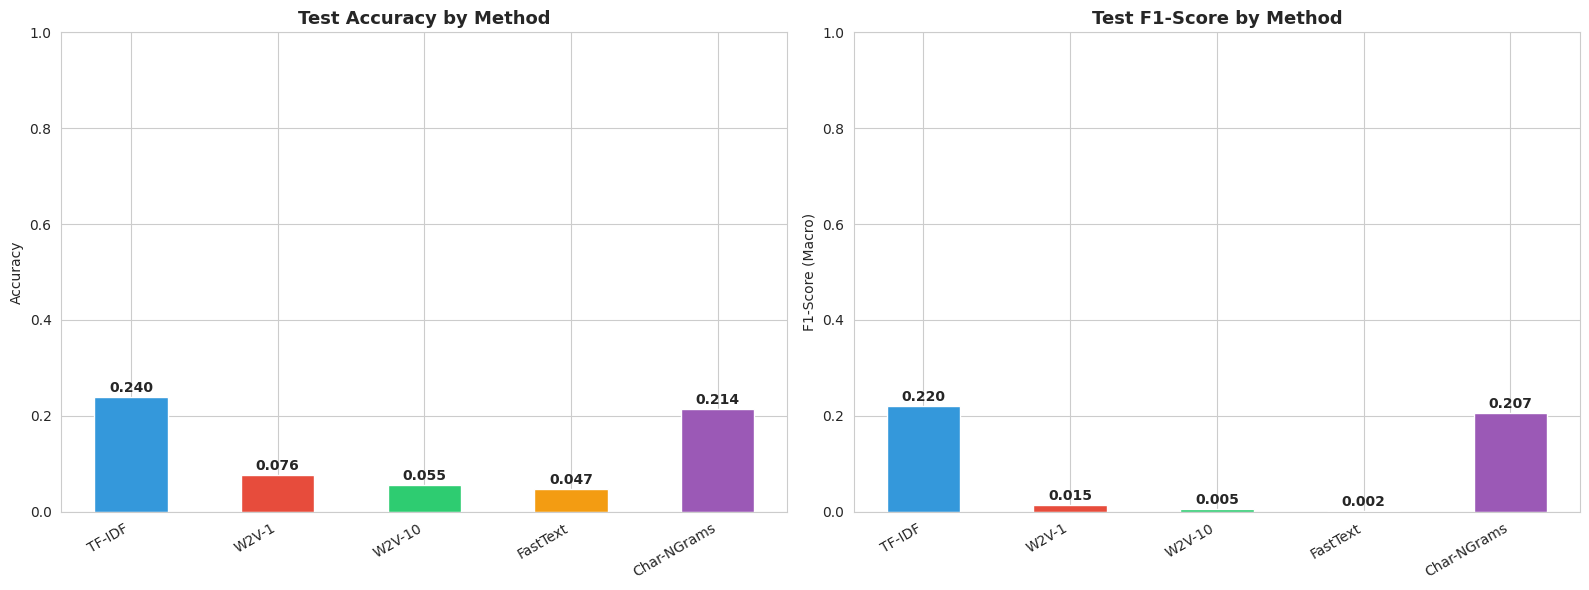


✓ Results saved!


In [18]:
all_results = [results_tfidf, results_w2v_1, results_w2v_10, results_ft, results_char]
results_df  = pd.DataFrame(all_results).set_index('tag')

print('\n' + '='*60)
print('TASK 1 — FINAL RESULTS')
print('='*60)
print(results_df[['val_acc', 'val_f1', 'test_acc', 'test_f1']].to_string())
print(f'\n✓ Best (Test Acc): {results_df["test_acc"].idxmax()}')
print(f'✓ Best (Test F1):  {results_df["test_f1"].idxmax()}')

methods  = results_df.index.tolist()
test_acc = results_df['test_acc'].values
test_f1  = results_df['test_f1'].values
colors   = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
x        = np.arange(len(methods))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars1 = axes[0].bar(x, test_acc, width=0.5, color=colors)
axes[0].set_title('Test Accuracy by Method', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=30, ha='right')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars1, test_acc):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontweight='bold')

bars2 = axes[1].bar(x, test_f1, width=0.5, color=colors)
axes[1].set_title('Test F1-Score by Method', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score (Macro)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=30, ha='right')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars2, test_f1):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

results_df.to_csv('/tmp/task1_results.csv')
print('\n✓ Results saved!')